🚀 Hızlı Mod: Veri hazırlanıyor...
🏎️ Modeller yarışıyor (Hızlı Mod)...
⏳ Decision Tree eğitiliyor...
⏳ Random Forest eğitiliyor...


C:\Users\uygrg\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 1 is smaller than n_iter=2. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


⏳ Gradient Boosting eğitiliyor...


C:\Users\uygrg\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 1 is smaller than n_iter=2. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



🏆 KAZANAN: Random Forest (Başarı: %68.4)


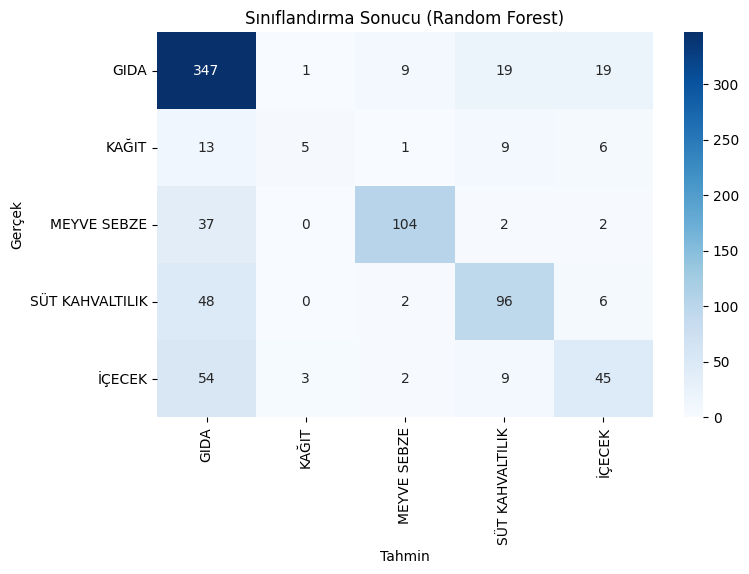


✅ BİTTİ! Sonuçlar yukarıda.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# --- 1. VERİ KONTROLÜ ---
if 'df' not in locals():
    olasi_yollar = ['MarketSales.xlsx', 'MarketSales.csv', '../MarketSales.xlsx', '../MarketSales.csv']
    for yol in olasi_yollar:
        if os.path.exists(yol):
            try:
                df = pd.read_excel(yol) if yol.endswith('xlsx') else pd.read_csv(yol)
                break
            except: continue

df.columns = df.columns.str.strip()

# --- 2. HIZLI VERİ HAZIRLIĞI ---
print("🚀 Hızlı Mod: Veri hazırlanıyor...")

# DİKKAT: 50.000 yerine 5.000 satır alıyoruz (Saniyeler sürsün diye)
df_class = df[['PRICE', 'AMOUNT', 'CATEGORY_NAME1']].dropna().sample(n=5000, random_state=42)

top_cats = df_class['CATEGORY_NAME1'].value_counts().head(5).index
df_class = df_class[df_class['CATEGORY_NAME1'].isin(top_cats)]

X = df_class[['PRICE', 'AMOUNT']]
y = df_class['CATEGORY_NAME1']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# --- 3. HIZLI AUTOML ---
print("🏎️ Modeller yarışıyor (Hızlı Mod)...")

models = {
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_jobs=-1), # Tüm çekirdekleri kullan
    'Gradient Boosting': GradientBoostingClassifier()
}

params = {
    'Decision Tree': {'max_depth': [5, 10]},
    'Random Forest': {'n_estimators': [50], 'max_depth': [10]},
    'Gradient Boosting': {'n_estimators': [50], 'learning_rate': [0.1]}
}

best_model = None
best_acc = 0
best_name = ""

for name, model in models.items():
    print(f"⏳ {name} eğitiliyor...")
    # cv=2 yaptık ki daha çabuk bitsin
    clf = RandomizedSearchCV(model, params[name], n_iter=2, cv=2, scoring='accuracy', n_jobs=-1, random_state=42)
    clf.fit(X_train, y_train)
    
    acc = clf.best_score_
    if acc > best_acc:
        best_acc = acc
        best_model = clf.best_estimator_
        best_name = name

print(f"\n🏆 KAZANAN: {best_name} (Başarı: %{best_acc*100:.1f})")

# --- 4. SONUÇ ---
final_preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Sınıflandırma Sonucu ({best_name})')
plt.xlabel('Tahmin'); plt.ylabel('Gerçek')
plt.show()

print("\n✅ BİTTİ! Sonuçlar yukarıda.")